In [167]:
import pandas as pd 
import numpy as np

In [168]:
df=pd.read_csv("Iris.csv")

In [169]:
import warnings
warnings.filterwarnings("ignore")

In [170]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [171]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [172]:
df.isna().sum().sum()

np.int64(0)

In [173]:
df.isnull().any()

Id               False
SepalLengthCm    False
SepalWidthCm     False
PetalLengthCm    False
PetalWidthCm     False
Species          False
dtype: bool

In [174]:
import matplotlib.pylab as plt
import seaborn as sns

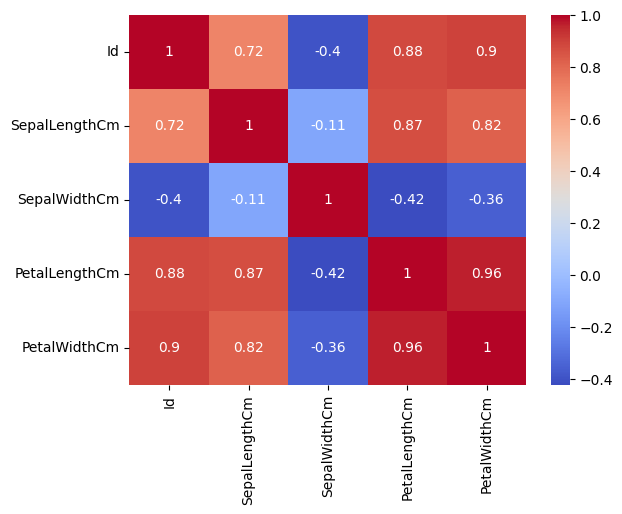

In [175]:
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm')

plt.show()

In [176]:
from scipy.stats import shapiro

for col in df.select_dtypes(include='number').columns:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p}")

Id: p-value = 8.080962238970425e-05
SepalLengthCm: p-value = 0.010181161454691156
SepalWidthCm: p-value = 0.07517918532015967
PetalLengthCm: p-value = 7.545419569615864e-10
PetalWidthCm: p-value = 1.8647596517271003e-08


In [177]:
#df=df.drop(columns=dff.columns[0])
df = df.drop(columns=['Id'])   # keep original dataset safe if needed

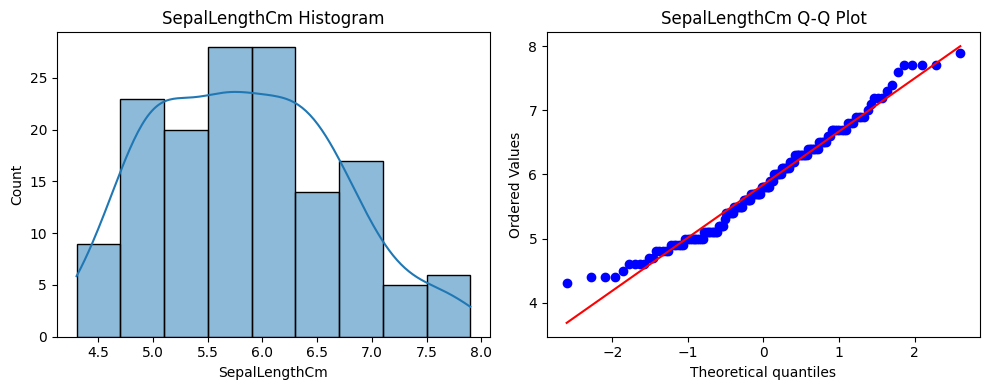

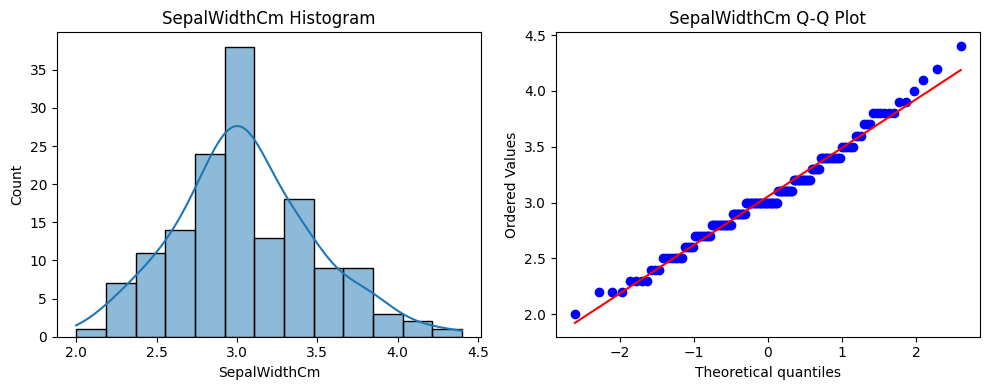

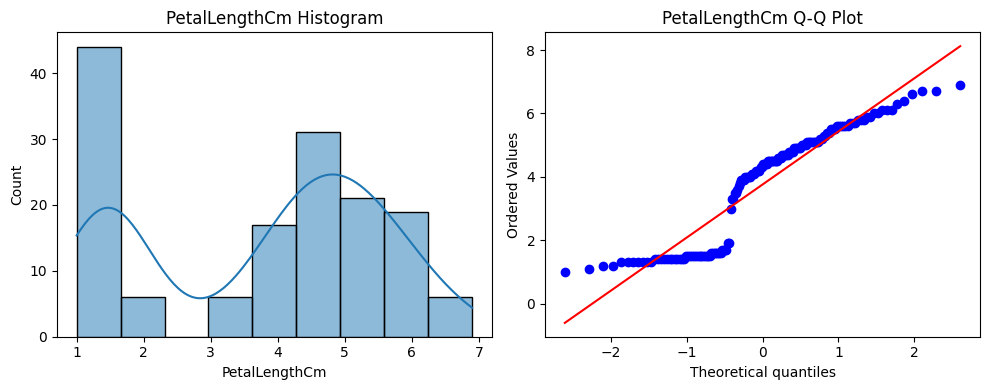

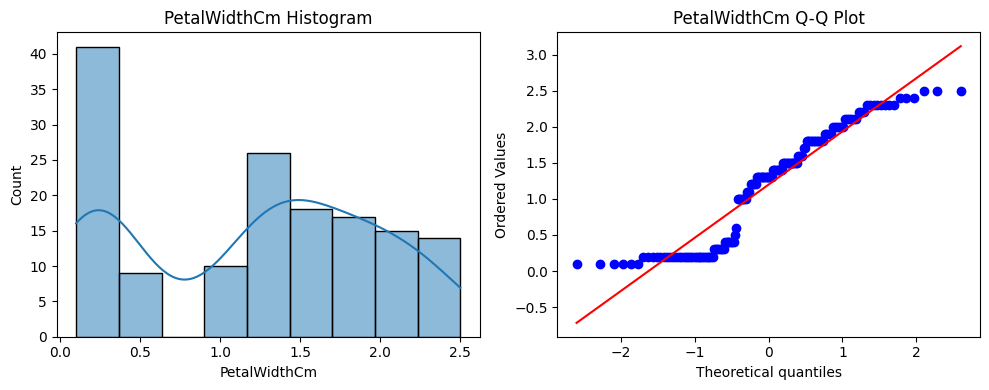

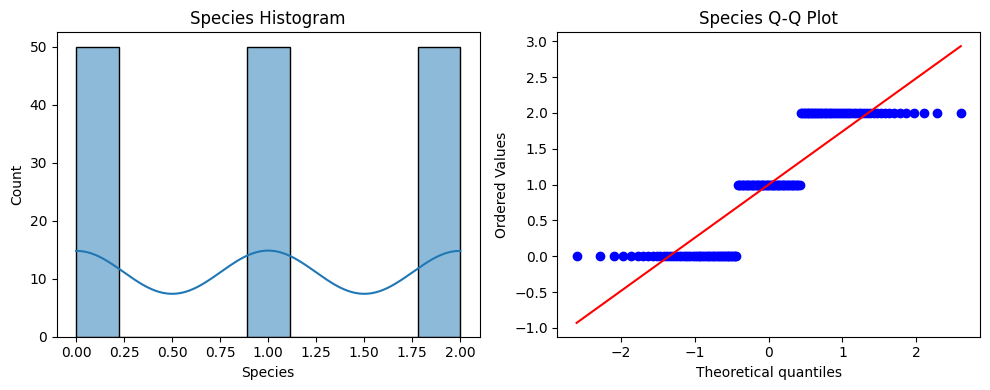

In [165]:
for col in df.select_dtypes(include='number').columns:
    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"{col} Histogram")

    stats.probplot(df[col], dist="norm", plot=ax[1])
    ax[1].set_title(f"{col} Q-Q Plot")

    plt.tight_layout()
    plt.show()

In [178]:
df.sum()

SepalLengthCm                                                876.5
SepalWidthCm                                                 458.1
PetalLengthCm                                                563.8
PetalWidthCm                                                 179.8
Species          Iris-setosaIris-setosaIris-setosaIris-setosaIr...
dtype: object

In [179]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [181]:
from sklearn.preprocessing import LabelEncoder

In [182]:
lb=LabelEncoder()

In [183]:
df['Species']=lb.fit_transform(df['Species'])

In [184]:
dff.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [185]:
df['Species'].unique()

array([0, 1, 2])

In [186]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [187]:
df.nunique()

SepalLengthCm    35
SepalWidthCm     23
PetalLengthCm    43
PetalWidthCm     22
Species           3
dtype: int64

In [188]:
X=df.drop("Species",axis=1)
y=df.Species

In [189]:
from sklearn.model_selection import train_test_split

In [190]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [191]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**1.Logistic Regression**

In [192]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [193]:
y_pred=model.predict(X_test)

In [194]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


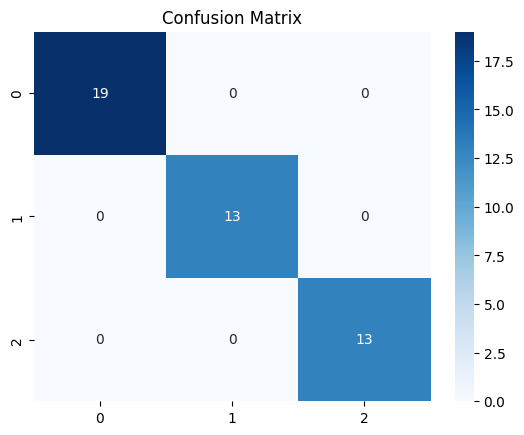

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [196]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [197]:
import numpy as np

sepal_length = float(input("Enter sepal length: "))
sepal_width  = float(input("Enter sepal width: "))
petal_length = float(input("Enter petal length: "))
petal_width  = float(input("Enter petal width: "))

input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

prediction = model.predict(input_data)

species_map = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

print("Predicted Species:", species_map[prediction[0]])

Enter sepal length:  2
Enter sepal width:  2
Enter petal length:  2
Enter petal width:  2


Predicted Species: Setosa


**2. Decision Tree (also basic + interpretable)**

In [209]:
model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [210]:
y_pred2 = model2.predict(X_test)

In [199]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


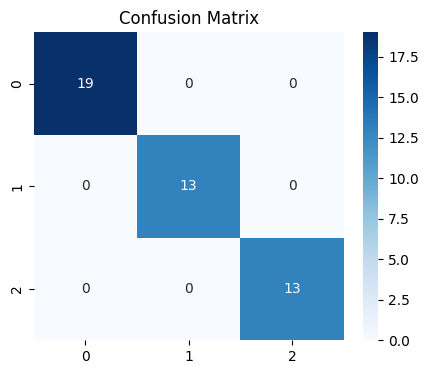

In [200]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [205]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [207]:
import numpy as np

sepal_length = float(input("Enter sepal length: "))
sepal_width  = float(input("Enter sepal width: "))
petal_length = float(input("Enter petal length: "))
petal_width  = float(input("Enter petal width: "))

input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

prediction = model2.predict(input_data)

species_map = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

print("Predicted Species:", species_map[prediction[0]])

Enter sepal length:  2
Enter sepal width:  2
Enter petal length:  2
Enter petal width:  2


Predicted Species: Setosa


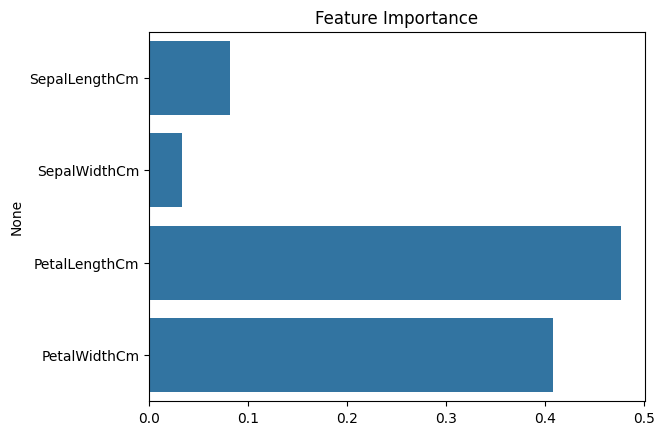

In [212]:
importances = model2.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance")
plt.show()